## Object Detection in MS COCO

In [1]:
import os
import torch
import numpy as np
from torchvision import transforms
#--------------------------------------------
from skimage.filters import gaussian
from scipy.ndimage import gaussian_filter
import cv2

import matplotlib.pyplot as plt

import shap_bpt
print('shap_bpt version:',shap_bpt.__version__)

shap_bpt version: 1.0


In [2]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("mps") if ('mps' in dir(torch.backends)) and torch.backends.mps.is_available() else torch.device("cpu")
device

device(type='cuda')

In [3]:
from ultralytics import YOLO

model = YOLO(f'yolo11s.pt')
class_names = model.names

print(f'{"Num_Classes":<15}{len(class_names)}')

model.info()

from pycocotools.coco import COCO

model_preprocess = transforms.Compose(
    [transforms.ToTensor()]
)

Num_Classes    80
YOLO11s summary: 319 layers, 9,458,752 parameters, 0 gradients, 21.7 GFLOPs


In [4]:
def load_image(fname,im_size=None,bg_type='black'):
    img_ = cv2.imread(f'{fname}')
    image_to_explain = cv2.cvtColor(img_, cv2.COLOR_BGR2RGB)                #.astype(np.float32)
    if im_size is not None:
        image_to_explain         = cv2.resize(image_to_explain,im_size)     # [:,:,::-1]
    image_to_explain_preproc  = image_to_explain.copy()                     #torch.tensor(image_to_explain).to(device)# .astype(np.float32)/255.0
    np.random.seed(0)
    bkgnd0 = np.full_like(image_to_explain, 0)
    bkgnd1 = np.full_like(image_to_explain, 127)
    bkgnd2 = np.full_like(image_to_explain, 255)
    bkgnd3 = gaussian(image_to_explain, 8, channel_axis=-1)*255
    bkgnd4 = np.clip(np.random.normal(128, 128, size=image_to_explain.shape), 0, 255).astype(np.uint8)
    bkgnd4 = (gaussian(bkgnd4, 2.0, channel_axis=-1) * 255).astype(np.uint8)
    if bg_type=='black': background_image_set = np.array([bkgnd0])
    elif bg_type=='gray': background_image_set = np.array([bkgnd1])
    elif bg_type=='white': background_image_set = np.array([bkgnd2])
    elif bg_type=='blurred': background_image_set = np.array([bkgnd3])
    elif bg_type=='noise': background_image_set = np.array([bkgnd4])
    elif bg_type=='full': background_image_set = np.array([bkgnd0, bkgnd1, bkgnd2, bkgnd3, bkgnd4])
    else: raise ValueError(f'Unknown bg_type: {bg_type}')
    background_image_preproc_set = [model_preprocess(bkgnd.astype(np.float32)/255.0)
                                        for bkgnd in background_image_set]
    background_tensors = torch.cat([torch.unsqueeze(bk_p, dim=0) 
                                    for bk_p in background_image_preproc_set]).to(device)
    return image_to_explain,image_to_explain_preproc,background_image_set,background_tensors

In [5]:

def predict_yolo(x,coco_classes_count=80,verbose=False):
    res = model.predict(source=x, verbose=verbose)[0]
    p = np.zeros(coco_classes_count)
    for cls,prob in zip(res.boxes.cls.cpu().numpy(), res.boxes.conf.cpu().numpy()):
        p[int(cls)] = prob
    return np.array(p)
#-----------------------------------------------------------------------
def predict_yolo_masked(masks,verbose=False):
    imglst_preds = []
    for mask in masks:
        preds = []
        for repl in background_image_set:
            # print(mask.shape, repl.shape)
            if len(mask.shape)!=3:
                mask3 = np.stack([mask,mask,mask], axis=2)
            else:
                print(mask.shape)
                mask3 = mask.copy()
            masked_image = np.where(mask3, image_to_explain, repl)
            preds.append(predict_yolo(masked_image,verbose=verbose))

        preds = np.mean(preds, axis=0)
        imglst_preds.append(preds)       
    
    return np.array(imglst_preds)

In [6]:
def load_image_to_explain(fname,bg_type='gray', load_gt=True):
    # global predicted_fS, predicted_f0, predicted_cls, sorted_classes, f_S, f_0,sorted_probs
    # global model_type,pretrained_model_type

    image_to_explain,image_to_explain_tensor,background_image_set,background_tensors = load_image(fname,bg_type=bg_type)
    h,w,_ = image_to_explain.shape
    # Foreground image to be explained  
    predicted_fS = predict_yolo(image_to_explain) 
    # predicted_fS = f(torch.unsqueeze(resnet50_preprocess(image_to_explain.astype(np.float32)/255.0).to(device), dim=0))[0]
    sorted_classes = np.flip(np.argsort(predicted_fS))
    sorted_probs   = predicted_fS[sorted_classes]
    predicted_cls = sorted_classes[0]
    f_S = float(predicted_fS[predicted_cls])
    #####################
    
    predicted_f0 = [predict_yolo(bkgnd.astype(np.float32)/255.0) for bkgnd in background_image_set]
    predicted_f0 = np.mean(predicted_f0,axis=0)
    f_0          = float(predicted_f0[predicted_cls])
    return image_to_explain,image_to_explain_tensor,background_image_set,background_tensors,predicted_fS,sorted_classes,sorted_probs,predicted_cls,f_S,predicted_f0,f_0
    # if load_gt:
        # image_no = int(image_path.split('\\')[-1].split('.')[0])

        # load_groundtruth(coco,image_path,fixed_category=fixed_category)
    

In [7]:
base_dir = 'D:\\DS\\MS_COCO'
image_dir = os.path.join(base_dir,'val2017')
annotation_file = f"{base_dir}//annotations//annotations_trainval2017//annotations//instances_val2017.json"  # Update for your annotation file

image_path = os.path.join(image_dir, '000000007281.jpg')

In [8]:
coco = COCO(annotation_file)

loading annotations into memory...
Done (t=0.52s)
creating index...
index created!


In [9]:
image_to_explain,image_to_explain_tensor,background_image_set,background_tensors,\
    predicted_fS,sorted_classes,sorted_probs,predicted_cls,f_S,predicted_f0,f_0 = load_image_to_explain(image_path, bg_type='gray')
# fixed_category = 'tv'
fixed_category = class_names[predicted_cls]
print('fixed_category: ',fixed_category)

fixed_category:  horse


In [10]:
image_no = 113235

image_info = coco.loadImgs(image_no)[0]
ann_ids = coco.getAnnIds(imgIds=image_info['id'])
annotations = coco.loadAnns(ann_ids)
has_segmentation = any('segmentation' in ann for ann in annotations)
print(f"Segmentation annotations present: {has_segmentation}")

Segmentation annotations present: True


In [11]:
categories = coco.loadCats(coco.getCatIds())
coco_categories = {cat['id']: cat['name'] for cat in categories}
# Get annotations for the selected image
ann_ids = coco.getAnnIds(imgIds=image_info['id'])
annotations = coco.loadAnns(ann_ids)

In [12]:
# # Check if segmentation annotations are present
# has_segmentation = any('segmentation' in ann for ann in annotations)
# print(f"Segmentation annotations present: {has_segmentation}")
# if has_segmentation:
#     for ann in annotations:
#         if 'segmentation' in ann:
#             print(f"Segmentation Annotation: {ann['segmentation']}")
#             break

In [13]:
def get_annotation(coco,image_no,category_name=None):
    if isinstance(image_no, str):
        image_no = int(image_no.split('\\')[-1].split('.')[0])
    
    image_info = coco.loadImgs(image_no)[0]
    if category_name is None:
        annotation_ids = coco.getAnnIds(imgIds=image_info['id'])
    else:
        category_ids = coco.getCatIds(catNms=[category_name])
        annotation_ids = coco.getAnnIds(imgIds=image_info['id'], catIds=category_ids)
    annotations = coco.loadAnns(annotation_ids)
    return annotations

def create_gt(coco,image_no,category_name=None, verbose=False):
    annotations = get_annotation(coco,image_no,category_name=category_name)
    if verbose:
        if len(annotations)>0:
            print(f"Image:{image_info['id']} has {len(annotations)} annotations")
    
    mask = np.zeros((image_info['height'], image_info['width']), dtype=np.uint8)
    category_mask = np.zeros((image_info['height'], image_info['width']), dtype=np.uint8)

    # Combine all masks for this image
    for ann in annotations:
        if 'segmentation' in ann:
            category_id = ann['category_id']  # Unique ID for object category
            # Decode the segmentation mask
            if isinstance(ann['segmentation'], list):  # Polygon format
                for seg in ann['segmentation']:
                    pts = np.array(seg).reshape(-1, 2).astype(np.int32)
                    cv2.fillPoly(mask, [pts], color=1)  # Fill the mask polygon
                    cv2.fillPoly(category_mask, [pts], color=category_id)
            elif isinstance(ann['segmentation'], dict):  # RLE format
                rle = ann['segmentation']
                decoded_mask = coco.annToMask(ann)
                mask += decoded_mask  # Add binary mask
                category_mask[decoded_mask > 0] = category_id  # Assign category ID
    
    # Resize masks to match actual image dimensions
    if mask.shape[:2] != image_to_explain.shape[:2]:
        # print(f"Resizing masks: Annotated={mask.shape}, Actual={image_to_explain.shape[:2]}")
        mask = cv2.resize(mask, (image_to_explain.shape[1], image_to_explain.shape[0]), interpolation=cv2.INTER_NEAREST)
        category_mask = cv2.resize(category_mask, (image_to_explain.shape[1], image_to_explain.shape[0]), interpolation=cv2.INTER_NEAREST)
    return mask,category_mask,annotations

In [14]:
def load_groundtruth(coco,image_no,fixed_category=None):
    global ground_truth,weighted_ground_truth,annotations
    mask,ground_truth,annotations = create_gt(coco,image_no,category_name = fixed_category)
    weighted_ground_truth = gaussian_filter(ground_truth.astype(float), 16) * ground_truth
    ground_truth.dtype = 'bool'

In [15]:
# Perform inference on an image
def plot_predictions(image, results, category_name=None, filter_preds=True, line_thickness=2, exp_type='demo', save_fig=False, fig_size=(3, 3), title=None, selected_ext='png', destroy_fig=False):
    image_ = image.copy()
    plt.figure(figsize=fig_size)
    plt.imshow(image_); plt.axis('off')
    for result in results:
        # Access detected classes, confidences, and boxes
        class_ids = result.boxes.cls.cpu().numpy()  # Class IDs
        scores = result.boxes.conf.cpu().numpy()   # Confidence scores
        boxes = result.boxes.xyxy.cpu().numpy()    # Bounding boxes in xyxy format
        labels = model.names                       # Class labels (MS COCO classes)
        # Draw bounding boxes and labels on the image
        for box, class_id, score in zip(boxes, class_ids, scores):
            label = labels[int(class_id)]
            confidence = f"{score:.2f}"
            x1, y1, x2, y2 = map(int, box)  # Bounding box coordinates
            if filter_preds and category_name and label != category_name:
                continue
            width,height = x2 - x1, y2 - y1
            plt.gca().add_patch(plt.Rectangle((x1, y1), width, height, edgecolor='darkred', facecolor='none', linewidth=line_thickness))
            plt.text(x1, y1 - 5, f"{label} {confidence}", color='white', fontsize=12, bbox=dict(facecolor='darkred', alpha=0.5))
    plt.show()


In [16]:
results = model.predict(image_to_explain,verbose=True)


0: 384x640 7 persons, 2 horses, 24.4ms
Speed: 6.9ms preprocess, 24.4ms inference, 3.6ms postprocess per image at shape (1, 3, 384, 640)


In [17]:
# Extract top-k classes
def get_top_k_classes(results, k=3):
    # Predictions contain bounding boxes with associated scores and classes
    class_names = model.names
    top_k = []
    for result_ in results:
        boxes = result_.boxes  # List of bounding boxes
        for box in boxes:
            score,class_id = box.conf, box.cls  # Confidence score, # Class ID
            top_k.append((int(class_id.item()),class_names[int(class_id.item())], score.item()))
        # Sort by confidence and take top-k
        top_k = sorted(top_k, key=lambda x: x[2], reverse=True)[:k]
    return top_k

In [18]:
top_classes_n = 5

top_k_classes = get_top_k_classes(results, k=top_classes_n)
print("Top-k Classes (Class ID, Confidence):", top_k_classes)
print([class_names[int(cls)] for cls, _,_ in top_k_classes])
print('-'*120)
print('top_k_classes \t', top_k_classes)

Top-k Classes (Class ID, Confidence): [(17, 'horse', 0.8502773642539978), (17, 'horse', 0.8355296850204468), (0, 'person', 0.8328522443771362), (0, 'person', 0.8062769174575806), (0, 'person', 0.7894089221954346)]
['horse', 'horse', 'person', 'person', 'person']
------------------------------------------------------------------------------------------------------------------------
top_k_classes 	 [(17, 'horse', 0.8502773642539978), (17, 'horse', 0.8355296850204468), (0, 'person', 0.8328522443771362), (0, 'person', 0.8062769174575806), (0, 'person', 0.7894089221954346)]


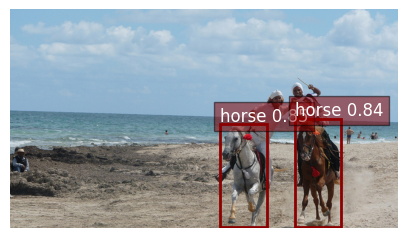

In [19]:
plot_predictions(image_to_explain,results,category_name = fixed_category,fig_size=(5,5), save_fig=False)

In [20]:
# MASKING FUNCTION
def predict_yolo_masked(masks):
    imglst_preds = []
    for mask in masks:
        preds = []
        for repl in background_image_set:
            if len(mask.shape)==2:
                mask3 = np.stack([mask,mask,mask], axis=2)
            else:
                mask3 = mask.copy()
            masked_image = np.where(mask3, image_to_explain, repl)
            preds.append(predict_yolo(masked_image))
        preds = np.mean(preds, axis=0)
        imglst_preds.append(preds)       
    return np.array(imglst_preds)

def predict_yolo(x,verbose=False):
    x = torch.from_numpy(x).to(device)
    x = x.cpu().numpy()
    res = model.predict(x,verbose=verbose)[0]
    p = np.zeros(80)
    for cls,prob in zip(res.boxes.cls.cpu().numpy(), res.boxes.conf.cpu().numpy()):
        p[int(cls)] = prob
    torch.cuda.empty_cache()
    return np.array(p)

In [21]:
print(image_to_explain.shape)
bg_ls = np.zeros((100,image_to_explain.shape[0],image_to_explain.shape[1],image_to_explain.shape[2]))
# bg_ls = np.random.randint(0, 255, (50,426, 640, 3), dtype=np.uint8)
print(bg_ls.shape)
pred = predict_yolo_masked(bg_ls)
print(pred.shape)
torch.cuda.empty_cache()

(361, 640, 3)
(100, 361, 640, 3)
(100, 80)


In [ ]:
num_explained_classes   = 4
num_samples             = 100
explainer   = shap_bpt.Explainer(predict_yolo_masked, image_to_explain, num_explained_classes=num_explained_classes, verbose=True)

In [23]:
shap_values_bpt = explainer.explain_instance(num_samples, method='BPT',batch_size=16)
shap_values_aa = explainer.explain_instance(num_samples, method='AA',  batch_size=16)

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

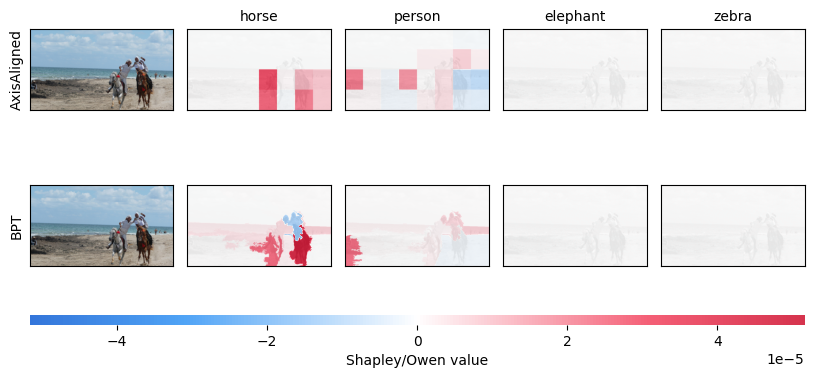

In [ ]:
## PLOT OWEN VALUES
# shap_bpt.plot_owen_values(explainer, [shap_values_aa],class_names, names=['AxisAligned'])
# shap_bpt.plot_owen_values(explainer, [shap_values_bpt],class_names, names=['BPT'])
shap_bpt.plot_owen_values(explainer, [shap_values_aa,shap_values_bpt],class_names, names=['AxisAligned','BPT'])